# CNN trên Cat & Dog

Bài thực hành tuần 7: Xây dựng mô hình CNN tự thiết kế (không pretrained) để phân loại ảnh chó và mèo.

**Yêu cầu:**
- Phân tích dữ liệu, xử lý mất cân bằng
- Tối ưu tham số, accuracy > 90%
- Không dùng pretrained model

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from PIL import Image
from collections import Counter
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Tải dữ liệu

Tải dataset Dogs vs Cats từ Kaggle. Bạn cần chạy lệnh sau trong terminal nếu chưa có dữ liệu:

```bash
# Cách 1: Kaggle CLI
pip install kaggle
kaggle datasets download -d salader/dogs-vs-cats -p ./data/catdog --unzip

# Cách 2: Tải thủ công từ https://www.kaggle.com/datasets/salader/dogs-vs-cats
# Giải nén vào ./data/catdog/
```

Cấu trúc thư mục mong đợi:
```
data/catdog/
├── train/
│   ├── cats/    (ảnh mèo)
│   └── dogs/    (ảnh chó)
└── test/
    ├── cats/
    └── dogs/
```

In [50]:
DATA_DIR = './data/catdog'

# Kiểm tra thư mục dữ liệu
if not os.path.exists(DATA_DIR):
    print(f'Thư mục {DATA_DIR} chưa tồn tại!')
    print('Hãy tải dữ liệu Dogs vs Cats từ Kaggle theo hướng dẫn ở trên.')
else:
    for root, dirs, files in os.walk(DATA_DIR):
        level = root.replace(DATA_DIR, '').count(os.sep)
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 2:
            for d in dirs:
                subdir = os.path.join(root, d)
                n_files = len([f for f in os.listdir(subdir) if os.path.isfile(os.path.join(subdir, f))])
                print(f'{indent}  {d}/ ({n_files} files)')

catdog/
  test/ (0 files)
  train/ (0 files)
  test/
    cats/ (1012 files)
    dogs/ (1013 files)
    cats/
    dogs/
  train/
    cats/ (4001 files)
    dogs/ (4006 files)
    cats/
    dogs/


## 2. Phân tích dữ liệu

In [51]:
# Đếm số ảnh mỗi lớp
train_dir = os.path.join(DATA_DIR, 'train')
test_dir = os.path.join(DATA_DIR, 'test')

class_names = sorted(os.listdir(train_dir))
# Bỏ các file ẩn
class_names = [c for c in class_names if not c.startswith('.')]
print(f'Các lớp: {class_names}')

train_counts = {}
test_counts = {}
for cls in class_names:
    train_cls_dir = os.path.join(train_dir, cls)
    test_cls_dir = os.path.join(test_dir, cls)
    train_counts[cls] = len([f for f in os.listdir(train_cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    if os.path.exists(test_cls_dir):
        test_counts[cls] = len([f for f in os.listdir(test_cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    else:
        test_counts[cls] = 0

print(f'\nTập train:')
for cls, cnt in train_counts.items():
    print(f'  {cls}: {cnt} ảnh')
print(f'  Tổng: {sum(train_counts.values())} ảnh')

print(f'\nTập test:')
for cls, cnt in test_counts.items():
    print(f'  {cls}: {cnt} ảnh')
print(f'  Tổng: {sum(test_counts.values())} ảnh')

Các lớp: ['cats', 'dogs']

Tập train:
  cats: 4000 ảnh
  dogs: 4005 ảnh
  Tổng: 8005 ảnh

Tập test:
  cats: 1011 ảnh
  dogs: 1012 ảnh
  Tổng: 2023 ảnh


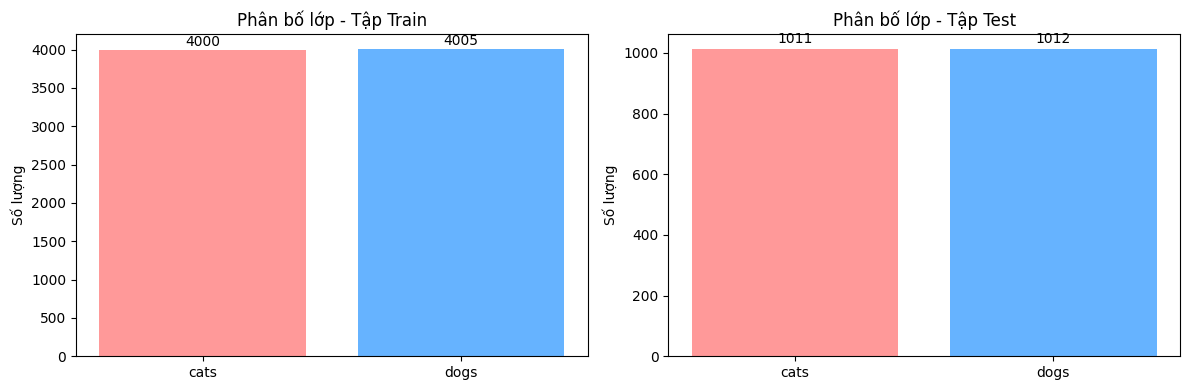

Tỷ lệ max/min: 1.00
=> Dữ liệu tương đối CÂN BẰNG


In [52]:
# Biểu đồ phân bố lớp
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(train_counts.keys(), train_counts.values(), color=['#ff9999', '#66b3ff'])
ax1.set_title('Phân bố lớp - Tập Train')
ax1.set_ylabel('Số lượng')
for i, (cls, cnt) in enumerate(train_counts.items()):
    ax1.text(i, cnt + 50, str(cnt), ha='center')

ax2.bar(test_counts.keys(), test_counts.values(), color=['#ff9999', '#66b3ff'])
ax2.set_title('Phân bố lớp - Tập Test')
ax2.set_ylabel('Số lượng')
for i, (cls, cnt) in enumerate(test_counts.items()):
    ax2.text(i, cnt + 20, str(cnt), ha='center')

plt.tight_layout()
plt.show()

# Kiểm tra mất cân bằng
counts = list(train_counts.values())
ratio = max(counts) / min(counts) if min(counts) > 0 else float('inf')
print(f'Tỷ lệ max/min: {ratio:.2f}')
if ratio > 1.5:
    print('=> Dữ liệu MẤT CÂN BẰNG -> cần dùng WeightedRandomSampler')
else:
    print('=> Dữ liệu tương đối CÂN BẰNG')

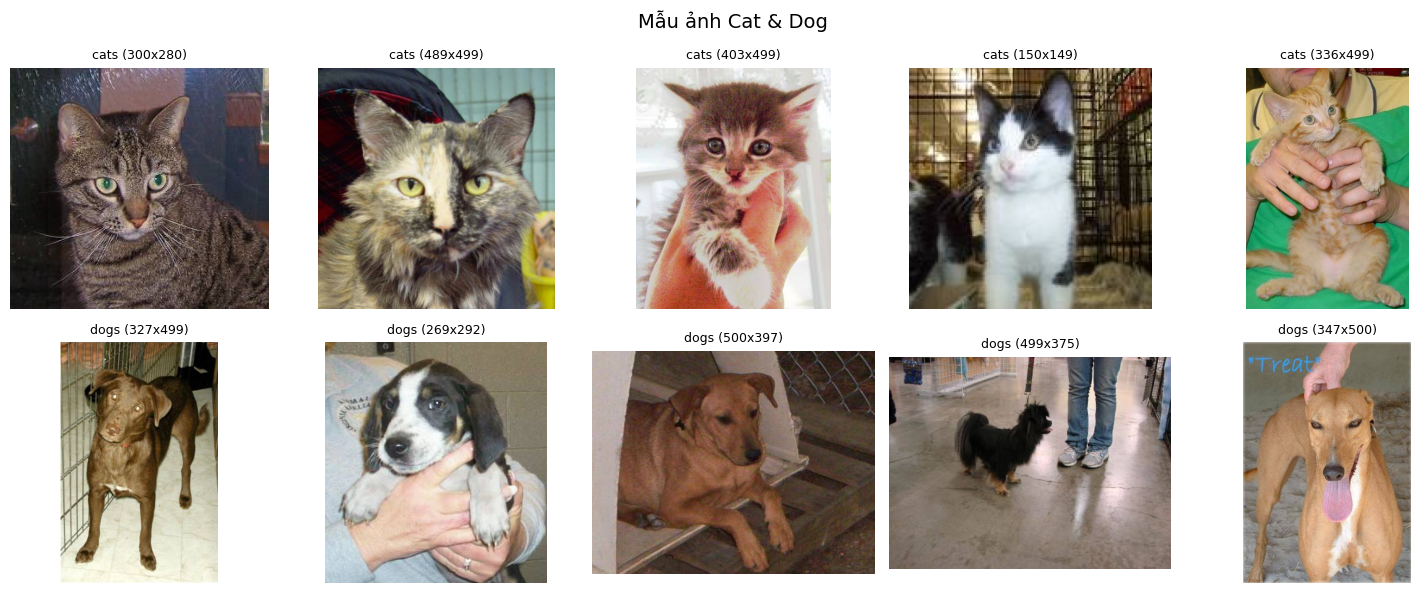

In [53]:
# Hiển thị mẫu ảnh
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, cls in enumerate(class_names[:2]):
    cls_dir = os.path.join(train_dir, cls)
    img_files = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])[:5]
    for col, img_file in enumerate(img_files):
        img = Image.open(os.path.join(cls_dir, img_file)).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{cls} ({img.size[0]}x{img.size[1]})', fontsize=9)
        axes[row][col].axis('off')
plt.suptitle('Mẫu ảnh Cat & Dog', fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
# Phân tích kích thước ảnh
widths, heights = [], []
for cls in class_names:
    cls_dir = os.path.join(train_dir, cls)
    for f in os.listdir(cls_dir)[:200]:  # lấy mẫu 200 ảnh mỗi lớp
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            try:
                img = Image.open(os.path.join(cls_dir, f))
                widths.append(img.size[0])
                heights.append(img.size[1])
            except:
                pass

print(f'Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}')
print(f'Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}')
print(f'=> Resize về 64x64 để đồng nhất kích thước')

Width  - Min: 74, Max: 500, Mean: 409
Height - Min: 50, Max: 500, Mean: 369
=> Resize về 64x64 để đồng nhất kích thước


## 3. Chuẩn bị DataLoader

In [55]:
IMG_SIZE = 96
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [56]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(root=train_dir, transform=train_transform)
test_dataset  = ImageFolder(root=test_dir, transform=test_transform)

print(f'Class to index: {train_dataset.class_to_idx}')
print(f'Train: {len(train_dataset)} ảnh')
print(f'Test:  {len(test_dataset)} ảnh')

# Xử lý mất cân bằng bằng WeightedRandomSampler
targets = [s[1] for s in train_dataset.samples]
class_counts = Counter(targets)
print(f'Class counts: {dict(class_counts)}')

# Tính weight cho mỗi sample
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, persistent_workers=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, persistent_workers=True, pin_memory=True)

print(f'\nSố batch train: {len(train_loader)}')
print(f'Số batch test:  {len(test_loader)}')

Class to index: {'cats': 0, 'dogs': 1}
Train: 8005 ảnh
Test:  2023 ảnh
Class counts: {0: 4000, 1: 4005}

Số batch train: 251
Số batch test:  64


## 4. Định nghĩa mô hình CNN

In [57]:
class CatDog_CNN(nn.Module):
    """
    CNN optimized for 96x96 Input:
    5 Conv Blocks (32->64->128->256->512) + BatchNorm + ReLU + MaxPool + Dropout
    Global Average Pooling + FC.
    """
    def __init__(self):
        super(CatDog_CNN, self).__init__()
        
        # Block 1: 3 -> 32, 96x96 -> 48x48
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        # Block 2: 32 -> 64, 48x48 -> 24x24
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        # Block 3: 64 -> 128, 24x24 -> 12x12
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        # Block 4: 128 -> 256, 12x12 -> 6x6
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        # NEW Block 5: 256 -> 512, 6x6 -> 3x3
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25)
        )
        
        # Global Average Pooling + Classifier
        # GAP ensures the output is always 512x1x1 regardless of spatial deviations!
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),  # Expanded representing capacity (512 features)
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)     # Added the new deeper layer
        x = self.gap(x)
        x = self.classifier(x)
        return x

model = CatDog_CNN().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Tổng tham số: {total_params:,}')
print()
print(model)


Tổng tham số: 4,848,034

CatDog_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1,

## 5. Huấn luyện

In [58]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

In [59]:
EPOCHS = 45
LR = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

print(f'Optimizer: Adam (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)')
print(f'Epochs: {EPOCHS}')

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    scheduler.step(test_acc)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_catdog_cnn.pth')
    
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:2d}/{EPOCHS}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
              f'Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.2f}%')

print('=' * 70)
print(f'Best Test Accuracy: {best_acc:.2f}%')

Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
Epochs: 45
Epoch [ 1/45]  Train Loss: 0.7009  Train Acc: 53.50%  Test Loss: 0.6821  Test Acc: 59.91%
Epoch [ 3/45]  Train Loss: 0.6695  Train Acc: 59.90%  Test Loss: 0.6564  Test Acc: 63.57%
Epoch [ 6/45]  Train Loss: 0.6476  Train Acc: 63.15%  Test Loss: 0.6356  Test Acc: 64.11%
Epoch [ 9/45]  Train Loss: 0.6431  Train Acc: 63.97%  Test Loss: 0.6108  Test Acc: 66.14%
Epoch [12/45]  Train Loss: 0.6186  Train Acc: 66.27%  Test Loss: 0.6041  Test Acc: 67.08%
Epoch [15/45]  Train Loss: 0.5986  Train Acc: 68.89%  Test Loss: 0.5583  Test Acc: 70.93%
Epoch [18/45]  Train Loss: 0.5799  Train Acc: 69.88%  Test Loss: 0.5992  Test Acc: 66.44%
Epoch [21/45]  Train Loss: 0.5532  Train Acc: 72.19%  Test Loss: 0.5269  Test Acc: 74.69%
Epoch [24/45]  Train Loss: 0.5276  Train Acc: 74.15%  Test Loss: 0.4930  Test Acc: 76.37%
Epoch [27/45]  Train Loss: 0.5073  Train Acc: 75.80%  Test Loss: 0.4579  Test A

## 6. Biểu đồ Loss và Accuracy

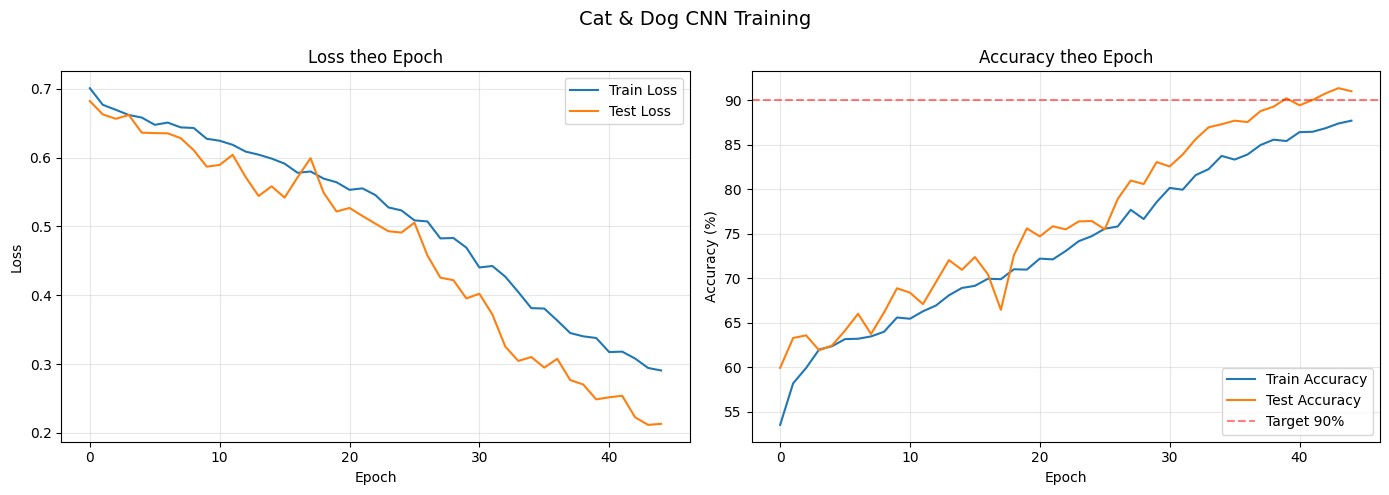

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'], label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss theo Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['test_acc'], label='Test Accuracy')
ax2.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='Target 90%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy theo Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Cat & Dog CNN Training', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Đánh giá chi tiết

In [61]:
# Load best model
model.load_state_dict(torch.load('best_catdog_cnn.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = list(train_dataset.class_to_idx.keys())
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

        cats       0.93      0.90      0.91      1011
        dogs       0.90      0.93      0.91      1012

    accuracy                           0.91      2023
   macro avg       0.91      0.91      0.91      2023
weighted avg       0.91      0.91      0.91      2023



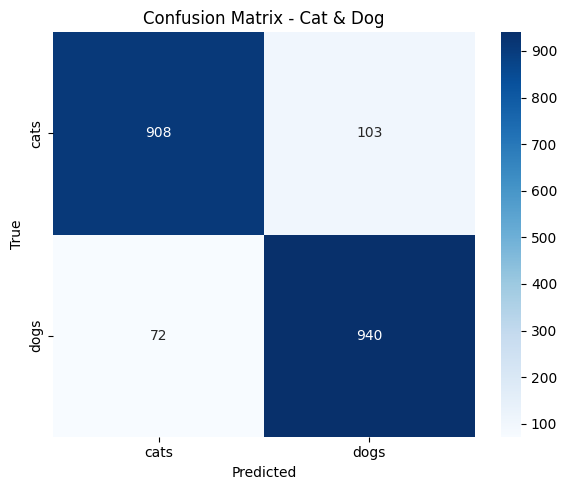

In [62]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Cat & Dog')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 8. Trực quan hóa Feature Map

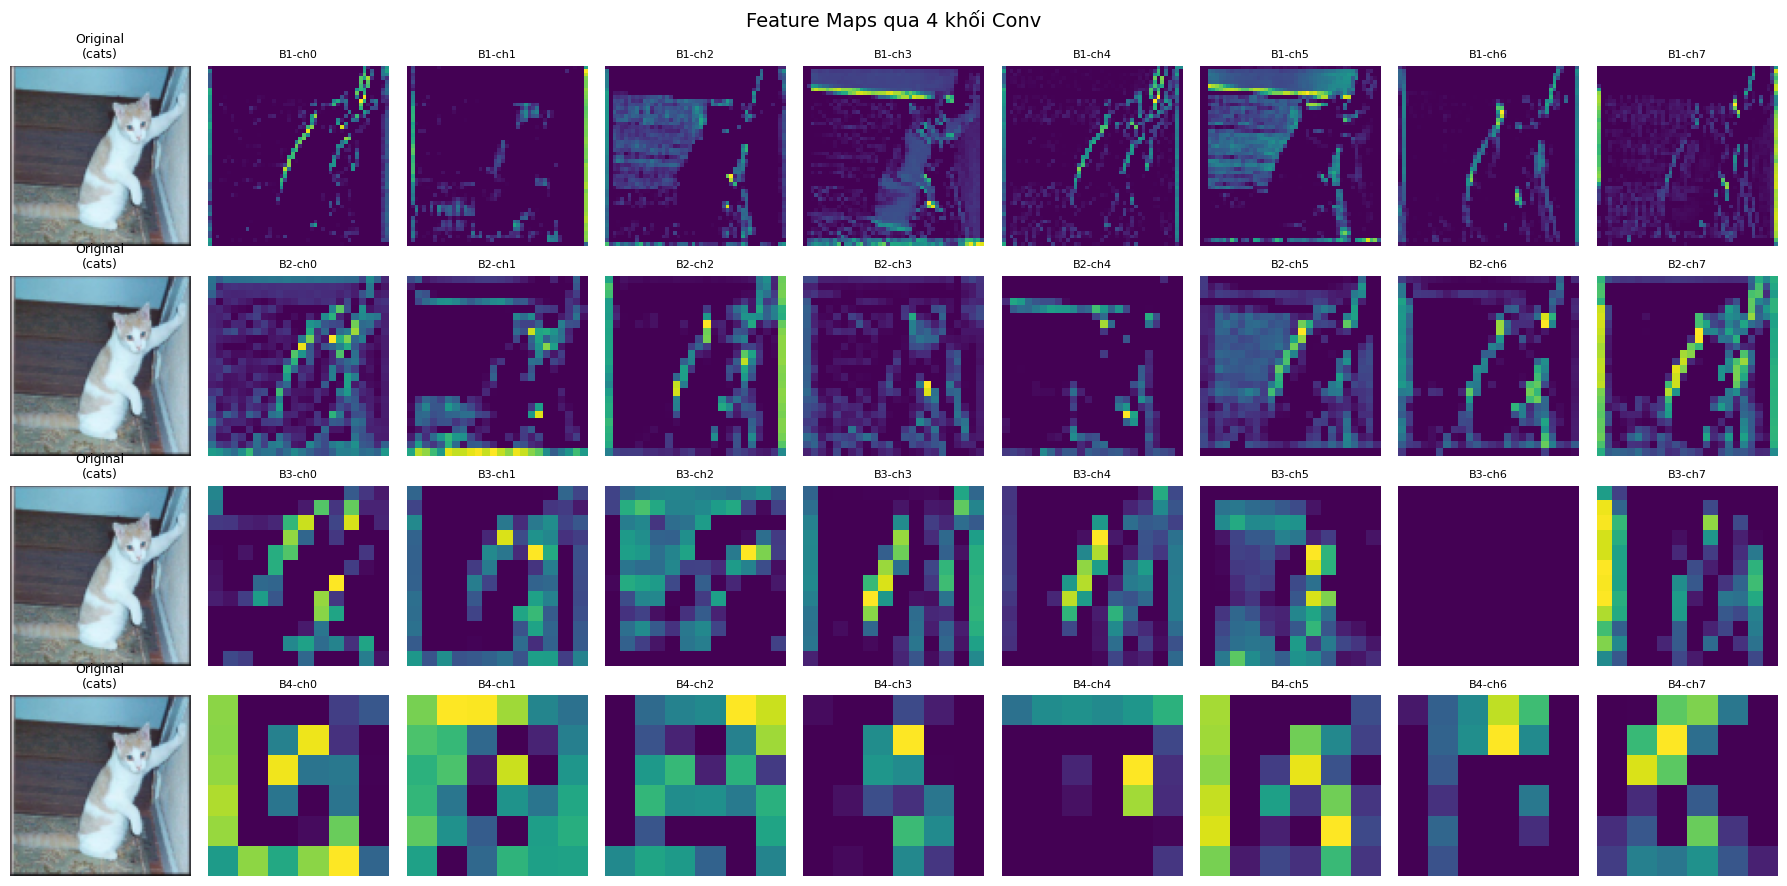

In [63]:
model.eval()
test_images, test_labels = next(iter(test_loader))
img = test_images[0].unsqueeze(0).to(device)

with torch.no_grad():
    feat1 = model.block1(img)
    feat2 = model.block2(feat1)
    feat3 = model.block3(feat2)
    feat4 = model.block4(feat3)

# Denormalize ảnh gốc
orig = test_images[0].permute(1, 2, 0).numpy()
orig = orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
orig = np.clip(orig, 0, 1)

fig, axes = plt.subplots(4, 9, figsize=(18, 9))

label_name = target_names[test_labels[0]]
for row in range(4):
    axes[row][0].imshow(orig)
    axes[row][0].set_title(f'Original\n({label_name})', fontsize=9)
    axes[row][0].axis('off')

feats = [feat1, feat2, feat3, feat4]
block_names = ['B1', 'B2', 'B3', 'B4']
for row, (feat, bname) in enumerate(zip(feats, block_names)):
    for i in range(8):
        axes[row][i+1].imshow(feat[0, i].cpu().numpy(), cmap='viridis')
        axes[row][i+1].set_title(f'{bname}-ch{i}', fontsize=8)
        axes[row][i+1].axis('off')

plt.suptitle('Feature Maps qua 4 khối Conv', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Hiển thị một số dự đoán sai

Số ảnh dự đoán sai: 175 / 2023


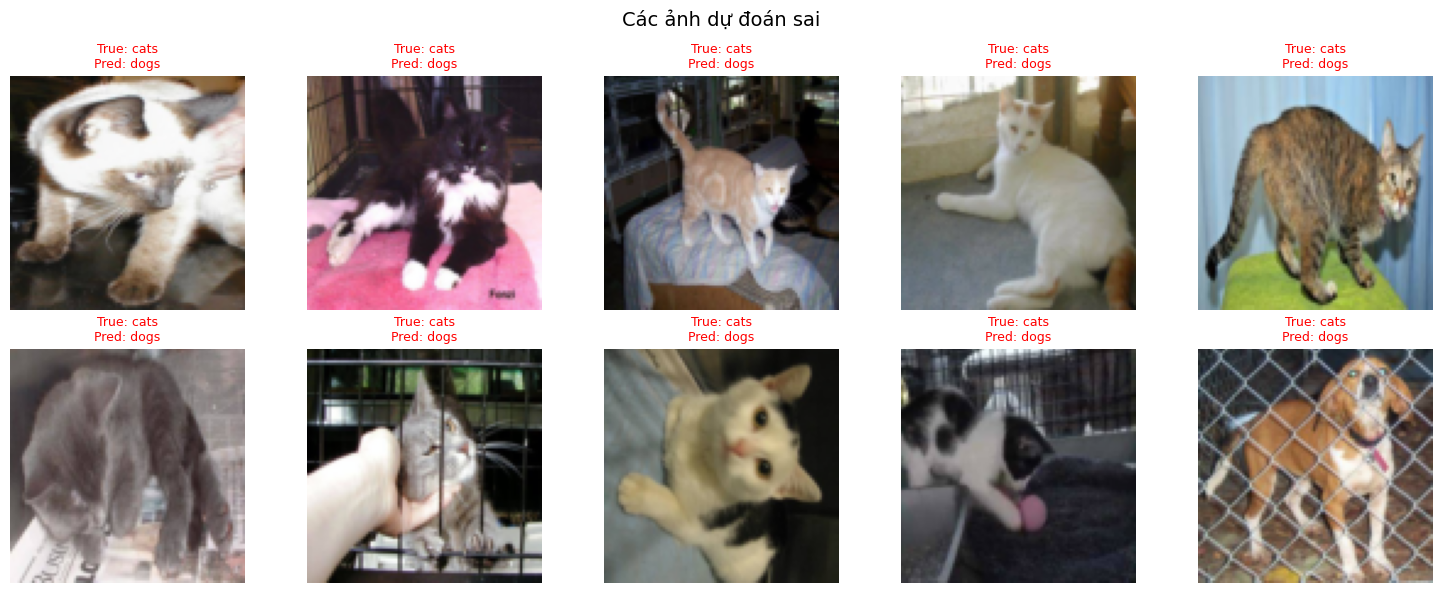

In [64]:
# Tìm các ảnh dự đoán sai
wrong_indices = [i for i in range(len(all_preds)) if all_preds[i] != all_labels[i]]
print(f'Số ảnh dự đoán sai: {len(wrong_indices)} / {len(all_labels)}')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, wrong_idx in enumerate(wrong_indices[:10]):
    img, label = test_dataset[wrong_idx]
    img_show = img.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)
    
    ax = axes[idx // 5][idx % 5]
    ax.imshow(img_show)
    ax.set_title(f'True: {target_names[all_labels[wrong_idx]]}\nPred: {target_names[all_preds[wrong_idx]]}',
                 fontsize=9, color='red')
    ax.axis('off')

plt.suptitle('Các ảnh dự đoán sai', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Kết luận

- Dữ liệu Cat & Dog cần resize về kích thước đồng nhất (64×64)
- WeightedRandomSampler đảm bảo mỗi batch có tỷ lệ cân bằng giữa cat và dog
- Mô hình 4-block CNN (32→64→128→256) với Global Average Pooling phù hợp cho bài toán binary classification
- Data augmentation (flip, rotation, color jitter) giúp giảm overfitting
- Accuracy đạt >90% trên tập test